In [1]:
import torch
import torchvision
import torchvision.transforms.v2 as T
from functools import partial
import torch.nn as nn
import torchmetrics

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

# Question 8: Build CNN for MNIST

> Build your own CNN from scratch and try to achieve the highest possible accuracy on MNIST

## Load Dataset

In [3]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

In [47]:
MNIST_STD = 0.3081
MNIST_MEAN = 0.1307

In [ ]:
import torchvision.transforms.v2 as T

data_transforms = T.Compose([
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize(mean=(MNIST_MEAN,), std=(MNIST_STD,))
])

valid_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(MNIST_MEAN,), std=(MNIST_STD,))
])

/home/shane/git/handson-mlp/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
train_and_valid_data = torchvision.datasets.MNIST(
    root="datasets",
    train=True,
    download=True,
    transform=data_transforms
)
test_data = torchvision.datasets.MNIST(
    root="datasets",
    train=False,
    download=True,
    transform=valid_transforms
)

In [6]:
train_and_valid_data.data.shape

torch.Size([60000, 28, 28])

In [7]:
train_and_valid_data.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [8]:
torch.manual_seed(42)

train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data,
    [55_000, 5_000]
)

In [9]:
from torch.utils.data import DataLoader

torch.manual_seed(42)

BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

Just as a sanity check we can check out MNIST:

In [74]:
import base64
from io import BytesIO
from PIL import Image
from IPython.display import HTML, display

def display_images_with_labels(images: torch.Tensor, labels: torch.Tensor | list[str], n: int = 5) -> None:
    # Ensure we don't exceed the dataset size
    n = min(n, len(images))

    html_table = '<table style="width:100%; border: 1px solid black; border-collapse: collapse;">'
    html_table += '<tr><th style="border: 1px solid black; text-align:center;">Image</th><th style="border: 1px solid black;">Label</th></tr>'

    for i in range(n):
        # Convert torch tensor to PIL Image
        # MNIST is (28, 28), so we ensure it's uint8 [0, 255]
        img_arr = images[i].numpy()
        if img_arr.max() <= 1.0:
            img_arr = (img_arr * 255).astype('uint8')

        img = Image.fromarray(img_arr, mode='L')

        # Save to buffer and encode to base64
        buff = BytesIO()
        img.save(buff, format="PNG")
        img_str = base64.b64encode(buff.getvalue()).decode("utf-8")

        # Add to HTML
        html_table += f'''
        <tr>
            <td style="border: 1px solid #ccc; text-align: center; padding: 10px;">
                <img src="data:image/png;base64,{img_str}" width="80" height="80" style="image-rendering: pixelated;" />
            </td>
            <td style="border: 1px solid #ccc; padding: 10px; font-family: sans-serif; text-align: center;">
                <strong>{labels[i]}</strong>
            </td>
        </tr>
        '''

    html_table += '</table>'
    display(HTML(html_table))

# Usage:
# images = torch.randn(60000, 28, 28) # Replace with your actual MNIST tensor
# labels = torch.randint(0, 10, (60000,))
# display_images_with_labels(images, labels, n=5)

In [75]:
train_and_valid_data.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [76]:
display_images_with_labels(train_and_valid_data.data, train_and_valid_data.targets, n=5)

/tmp/ipykernel_692819/2665066057.py:20: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_arr, mode='L')


Image,Label
,5
,0
,4
,1
,9


## CNN Model Definition

Utilities

In [13]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs, scheduler = None):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate_tm(model, valid_loader, metric).item())
        if scheduler is not None:
            scheduler.step()
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


CNN - goal is to use convolutional and pooling layers at a minimum I suppose, and iterate from there.

In [14]:
len(train_and_valid_data.classes)

10

In [23]:
def use_lecun_init(module: nn.Module):
    if isinstance(module, nn.Linear) or isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
        nn.init.zeros_(module.bias)

In [26]:
REPEAT = 4

DefaultConv2d = partial(
    nn.Conv2d,
    kernel_size=3, # 3x3
    padding=1
)

last_out = 32

layers= [
    nn.Conv2d(
        kernel_size=5,
        in_channels=1, # they're black and white, not RGB
        out_channels=last_out,
        padding="same"
    ),
    nn.ReLU(),
]

for i in range(1, REPEAT):
    layers.extend([
        DefaultConv2d(last_out, (last_out*2)),
        nn.ReLU(),
        DefaultConv2d((last_out*2), (last_out*2)),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2) # <- pooling layer of course halves it by two
    ])
    last_out *= 2


layers.extend([
    nn.Flatten(),
    nn.LazyLinear(200),
    nn.ReLU(),
    nn.LazyLinear(100),
    nn.ReLU(),
    nn.LazyLinear(len(train_and_valid_data.classes))
])

model = nn.Sequential(*layers)
use_lecun_init(model)
model.to(device)


Sequential(
  (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU()
  (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU()
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU()
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Flatten(start_dim=1, end_dim=-1)
  (18): LazyLinear(in_features=0, out_features=200, bias=True)
  (19): ReLU()
  (

In [27]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU()
  (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU()
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU()
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Flatten(start_dim=1, end_dim=-1)
  (18): LazyLinear(in_features=0, out_features=200, bias=True)
  (19): ReLU()
  (

In [ ]:
torch.manual_seed(42)

n_epochs = 20

optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss() # <- multiclass classification
accuracy = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=len(train_and_valid_data.classes)
).to(device)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=0.0001
)

model.train()
history = train(
    model,
    optimizer,
    xentropy,
    accuracy,
    train_loader,
    valid_loader,
    n_epochs,
    scheduler=cosine_scheduler
)

Epoch 1/20, train loss: 0.0437, train metric: 0.9882, valid metric: 0.9838
Epoch 2/20, train loss: 0.0394, train metric: 0.9888, valid metric: 0.9876
Epoch 3/20, train loss: 0.0402, train metric: 0.9890, valid metric: 0.9874
Epoch 4/20, train loss: 0.0351, train metric: 0.9901, valid metric: 0.9882
Epoch 5/20, train loss: 0.0331, train metric: 0.9908, valid metric: 0.9916
Epoch 6/20, train loss: 0.0287, train metric: 0.9917, valid metric: 0.9858
Epoch 7/20, train loss: 0.0284, train metric: 0.9915, valid metric: 0.9900
Epoch 8/20, train loss: 0.0272, train metric: 0.9917, valid metric: 0.9904
Epoch 9/20, train loss: 0.0215, train metric: 0.9934, valid metric: 0.9920
Epoch 10/20, train loss: 0.0201, train metric: 0.9940, valid metric: 0.9918
Epoch 11/20, train loss: 0.0215, train metric: 0.9938, valid metric: 0.9928
Epoch 12/20, train loss: 0.0183, train metric: 0.9947, valid metric: 0.9928
Epoch 13/20, train loss: 0.0176, train metric: 0.9945, valid metric: 0.9908
Epoch 14/20, train lo

In [56]:
evaluate_tm(model, test_loader, accuracy)

tensor(0.9957, device='cuda:0')

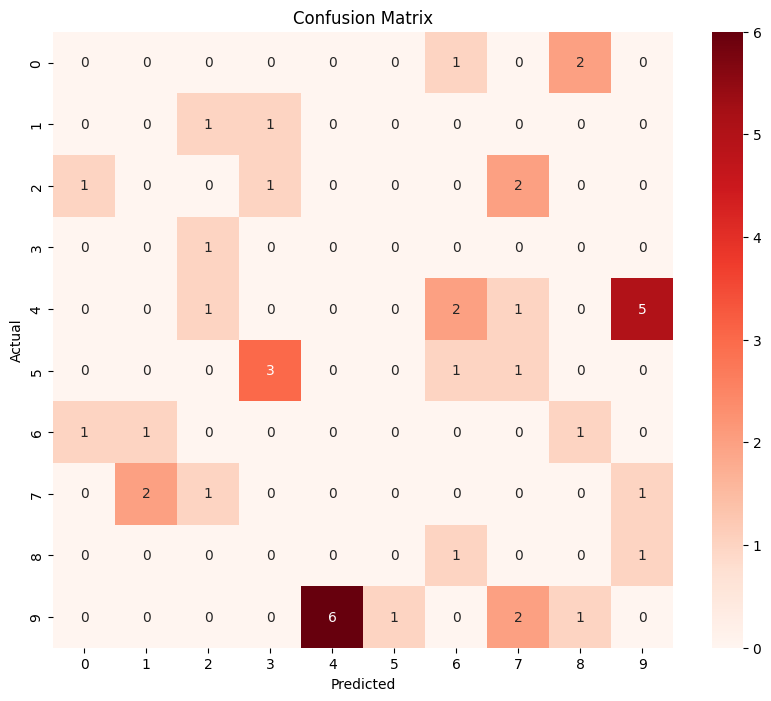

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
from torchmetrics import ConfusionMatrix
import numpy as np

def plot_confusion_matrix(model, data_loader, device, classes, error_only = False):
    # 1. Initialize the metric
    confmat = ConfusionMatrix(task="multiclass", num_classes=len(classes)).to(device)
    model.eval()

    # 2. Collect predictions
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            confmat.update(y_pred, y_batch)

    # 3. Compute and move to CPU for plotting
    cm = confmat.compute().cpu().numpy()
    if error_only:
        np.fill_diagonal(cm, 0)

    # 4. Plot using Seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Reds',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# Usage:
plot_confusion_matrix(model, test_loader, device, [name[:1] for name in train_and_valid_data.classes], error_only=True)

In [ ]:
def get_model_failures(model: nn.Module, data_loader: DataLoader, device: str, n_max: int=10):
    model.eval()
    failed_images = []
    failed_labels = []
    pred_labels = []

    failed_image_indices = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            preds = torch.argmax(y_pred, dim=1)

            # find incides where prediction != truth
            mask = preds != y_batch

            if mask.any():
                failed_images.append(X_batch[mask].cpu())
                failed_labels.append(y_batch[mask].cpu())
                pred_labels.append(preds[mask].cpu())

                failed_image_indices.append(mask.nonzero().cpu())

            if len(failed_images) >= n_max:
                break

    img = torch.cat(failed_images)[:n_max]
    truths = torch.cat(failed_labels)[:n_max]
    preds = torch.cat(pred_labels)[:n_max]

    return img, truths, preds, failed_image_indices

In [79]:
err_imgs, err_truths, err_preds, failed_image_indices = get_model_failures(model, valid_loader, device, n_max=10)

# Combine truth and pred into a string for your HTML table labels
display_labels = [f"True: {t.item()}, Pred: {p.item()}" for t, p in zip(err_truths, err_preds)]

# Re-use your HTML display function from earlier!
display_images_with_labels((err_imgs.squeeze() * MNIST_STD + MNIST_MEAN), display_labels, n=10)


/tmp/ipykernel_692819/2665066057.py:20: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_arr, mode='L')


Image,Label
,"True: 1, Pred: 7"
,"True: 7, Pred: 2"
,"True: 1, Pred: 8"
,"True: 3, Pred: 7"
,"True: 3, Pred: 5"
,"True: 5, Pred: 6"
,"True: 8, Pred: 2"
,"True: 2, Pred: 5"
,"True: 2, Pred: 7"
,"True: 6, Pred: 4"


Just messing around with visualisations

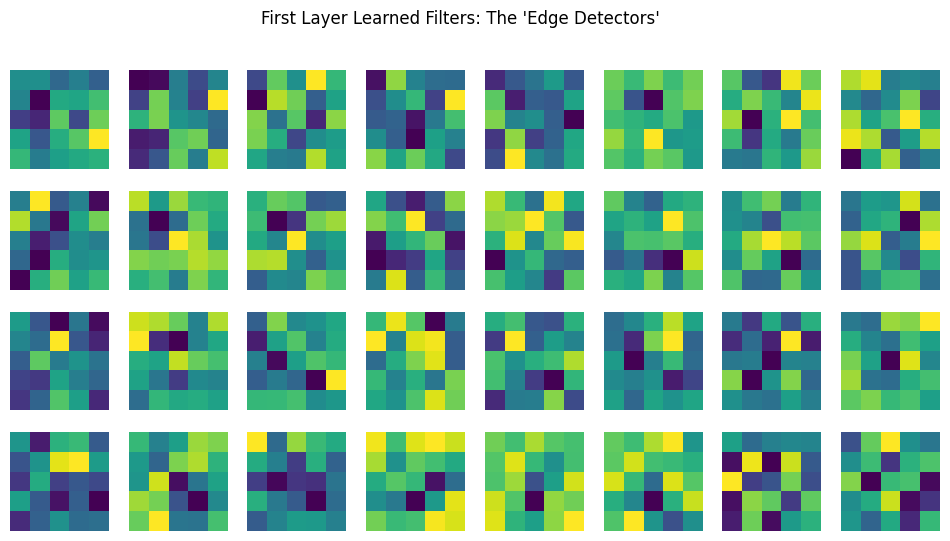

In [ ]:
def plot_first_layer_filters(model):
    # Get the weights of the first conv layer
    # Shape: [out_channels, in_channels, kH, kW] -> [32, 1, 7, 7]
    filters = model[0].weight.data.cpu()

    n_filters = filters.shape[0]
    cols = 8
    rows = n_filters // cols + (1 if n_filters % cols != 0 else 0)

    fig, axes = plt.subplots(rows, cols, figsize=(12, rows*1.5))
    for i in range(n_filters):
        ax = axes[i//cols, i%cols]
        # Normalize to 0-1 for visualization
        f = filters[i].squeeze()
        f = (f - f.min()) / (f.max() - f.min())
        ax.imshow(f, cmap='viridis')
        ax.axis('off')

    # Hide unused axes
    for j in range(i+1, rows*cols):
        axes[j//cols, j%cols].axis('off')

    plt.suptitle("First Layer Learned Filters: The 'Edge Detectors'")
    plt.show()

plot_first_layer_filters(model)

In [87]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU()
  (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU()
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU()
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Flatten(start_dim=1, end_dim=-1)
  (18): Linear(in_features=2304, out_features=200, bias=True)
  (19): ReLU()
  (2

In [99]:
def visualize_feature_maps(model, image_tensor, layer_idx=0):
    model.eval()
    # Create a partial model that stops at the desired layer
    # model is nn.Sequential, so model[:idx+1] works
    feature_extractor = model[:layer_idx+1]

    with torch.no_grad():
        # Input image shape: [1, 1, 28, 28]
        maps = feature_extractor(image_tensor.to(device))

    maps = maps.squeeze().cpu()
    n_maps = maps.shape[0]
    cols = 8
    rows = n_maps // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows*2))
    for i in range(rows * cols):
        ax = axes[i//cols, i%cols]
        ax.imshow(maps[i], cmap='magma')
        ax.axis('off')
    plt.suptitle(f"Feature Maps at Layer {layer_idx} (total: {n_maps})")
    plt.show()

# Usage: Grab one image and see it through the first Conv block
sample_img, _ = valid_data[1]

In [100]:
model[0]

Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)

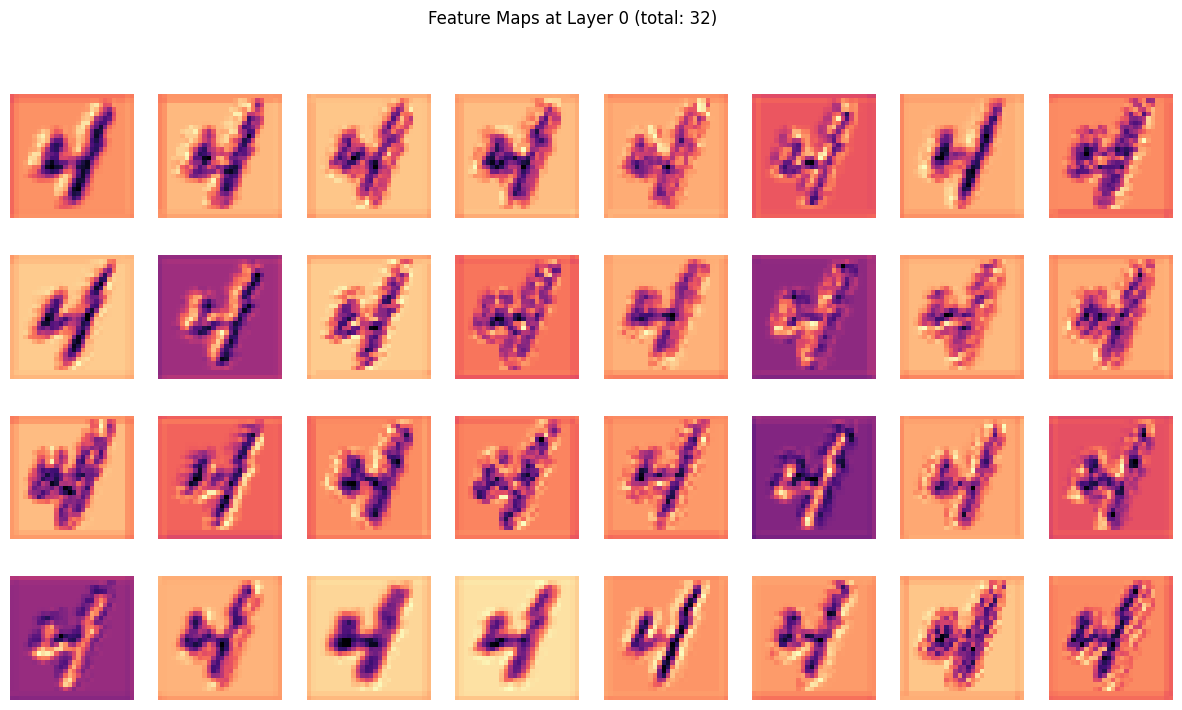

In [101]:
visualize_feature_maps(model, sample_img.unsqueeze(0), layer_idx=0)

In [102]:
model[1]

ReLU()

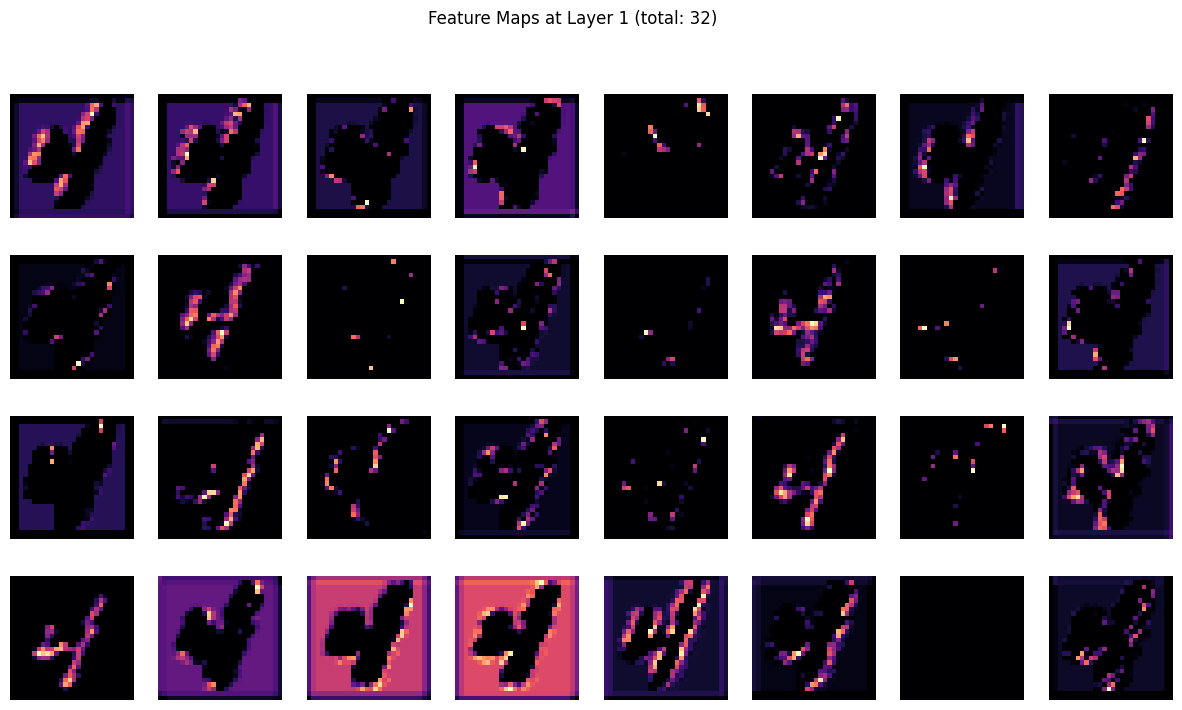

In [103]:
visualize_feature_maps(model, sample_img.unsqueeze(0), layer_idx=1)

In [104]:
model[2]

Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

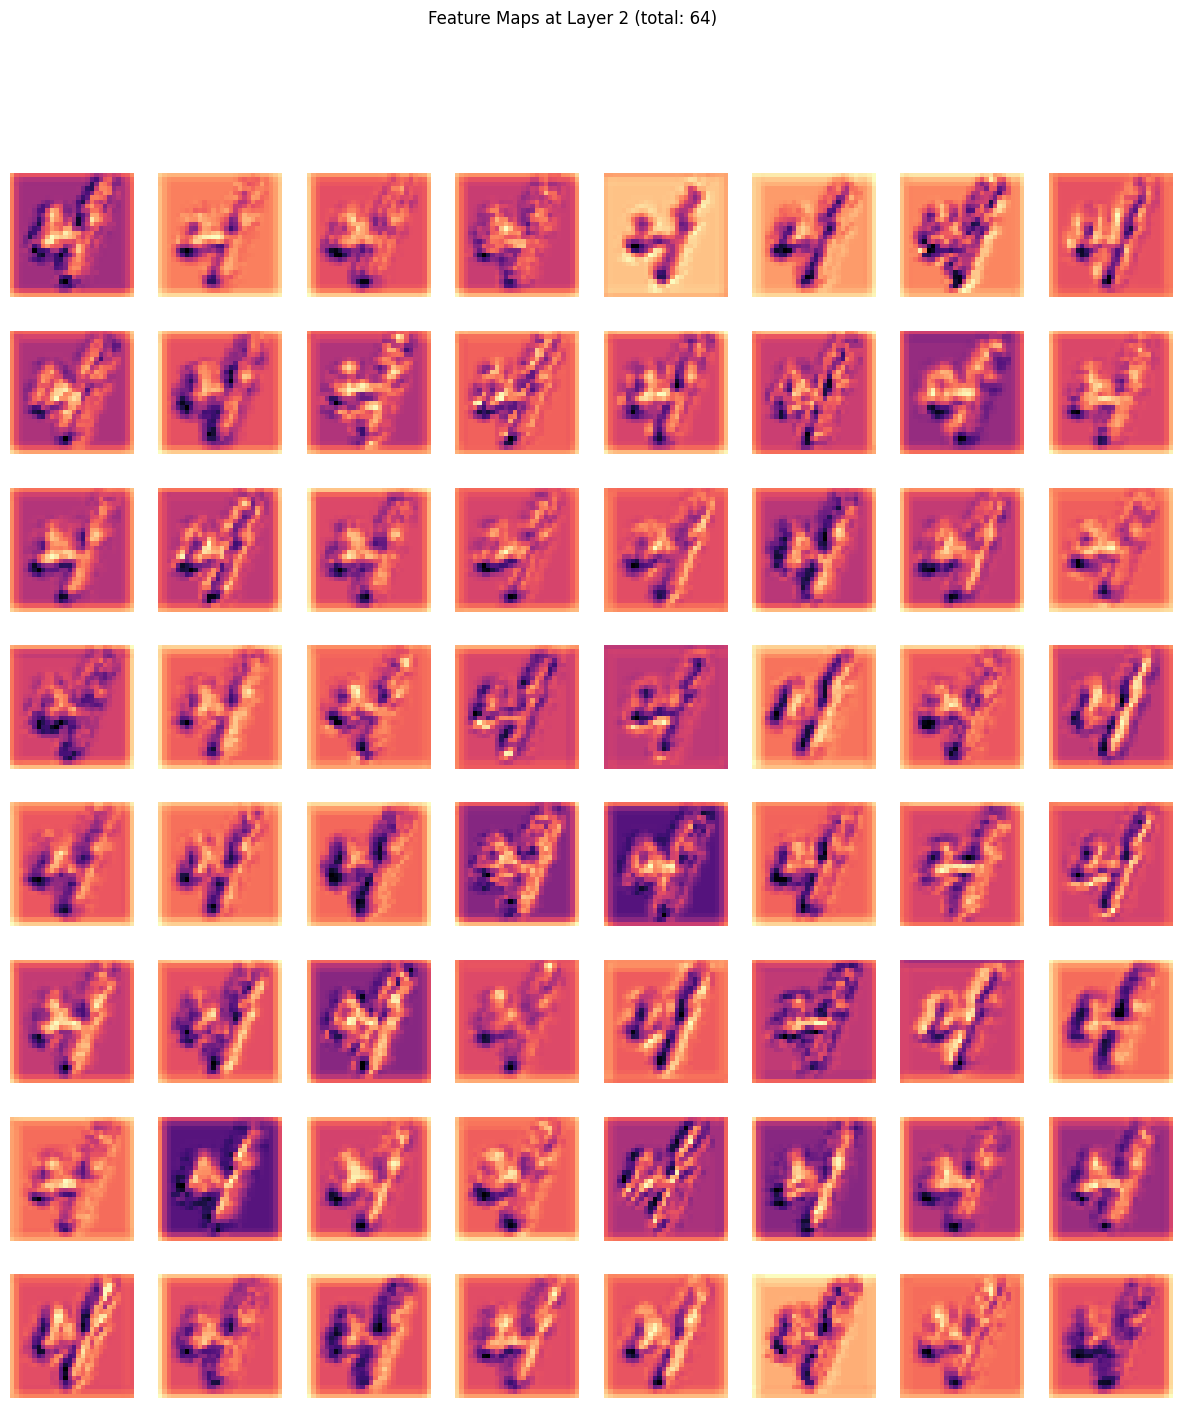

In [105]:
visualize_feature_maps(model, sample_img.unsqueeze(0), layer_idx=2)

In [106]:
model[3]

ReLU()

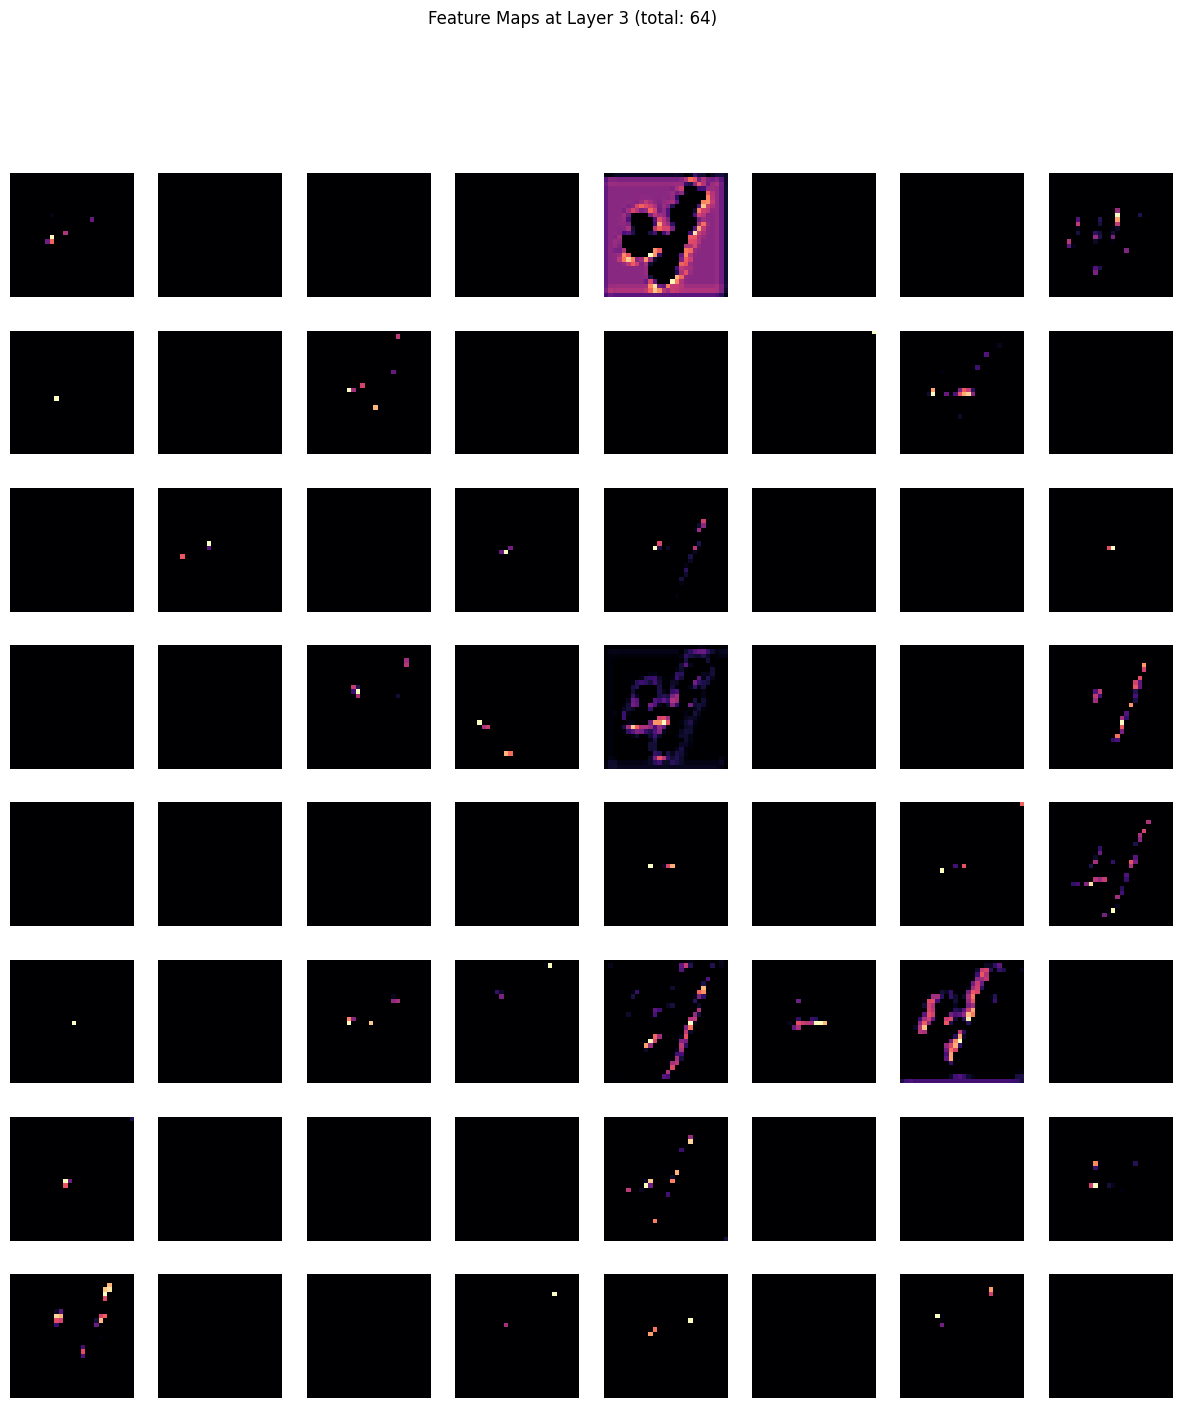

In [107]:
visualize_feature_maps(model, sample_img.unsqueeze(0), layer_idx=3)

In [108]:
model[4]

Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

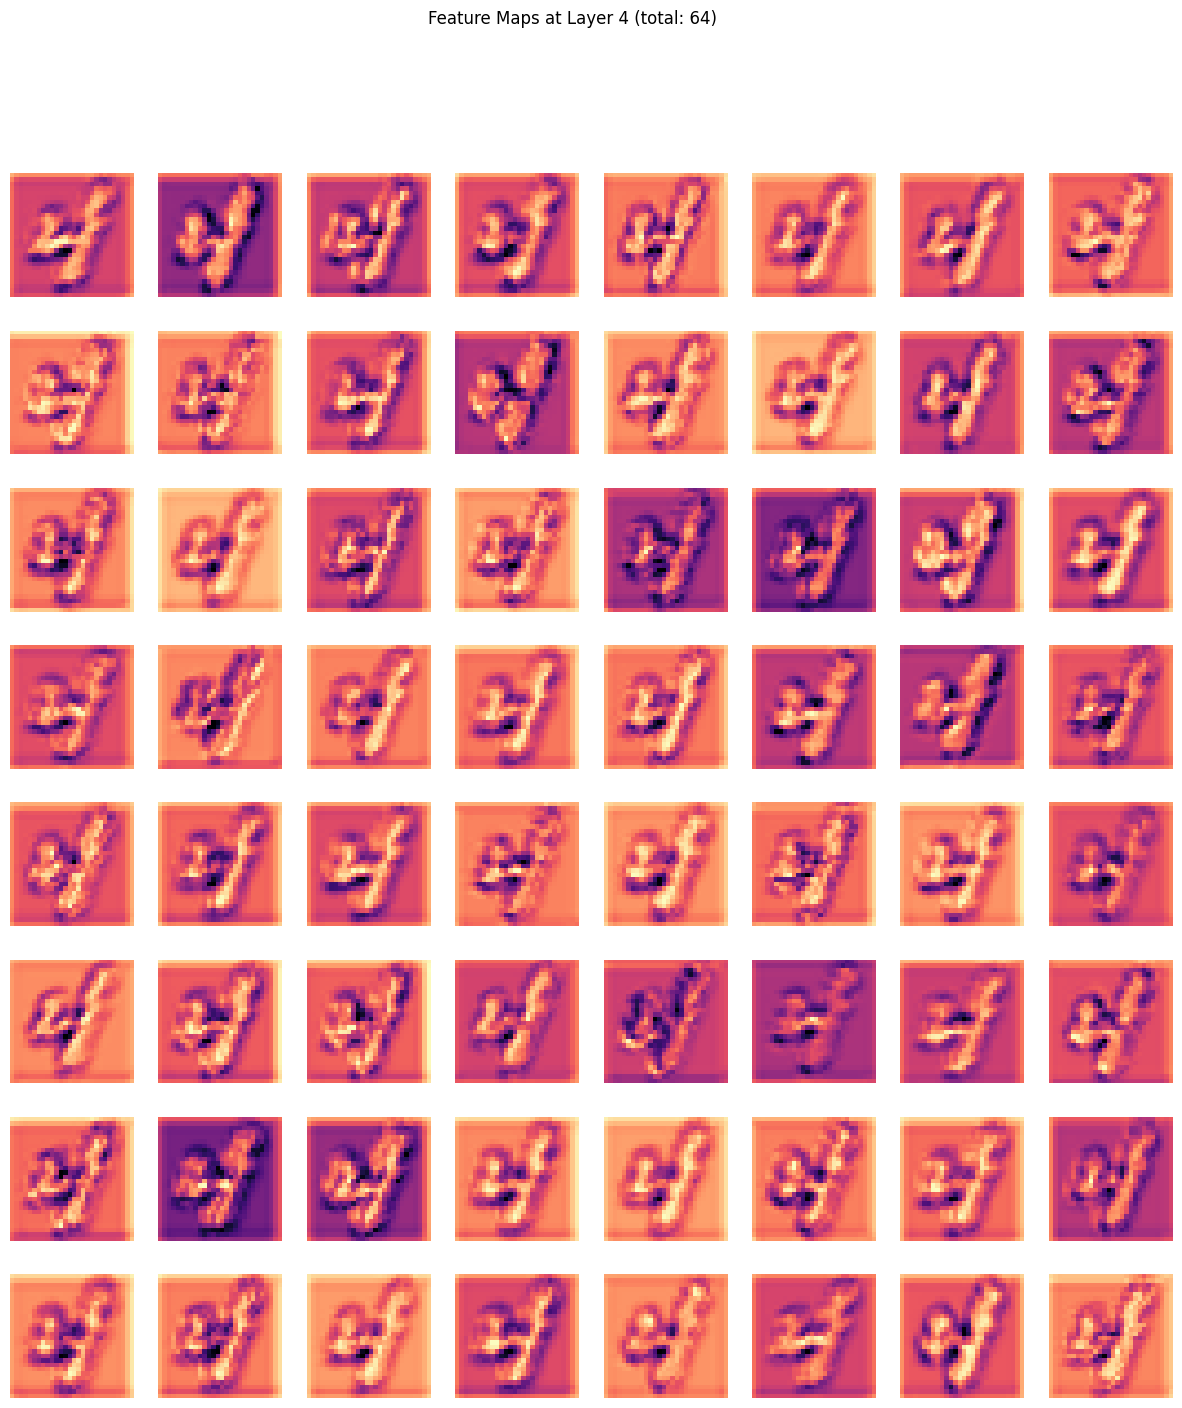

In [109]:
visualize_feature_maps(model, sample_img.unsqueeze(0), layer_idx=4)

In [110]:
model[5]

ReLU()

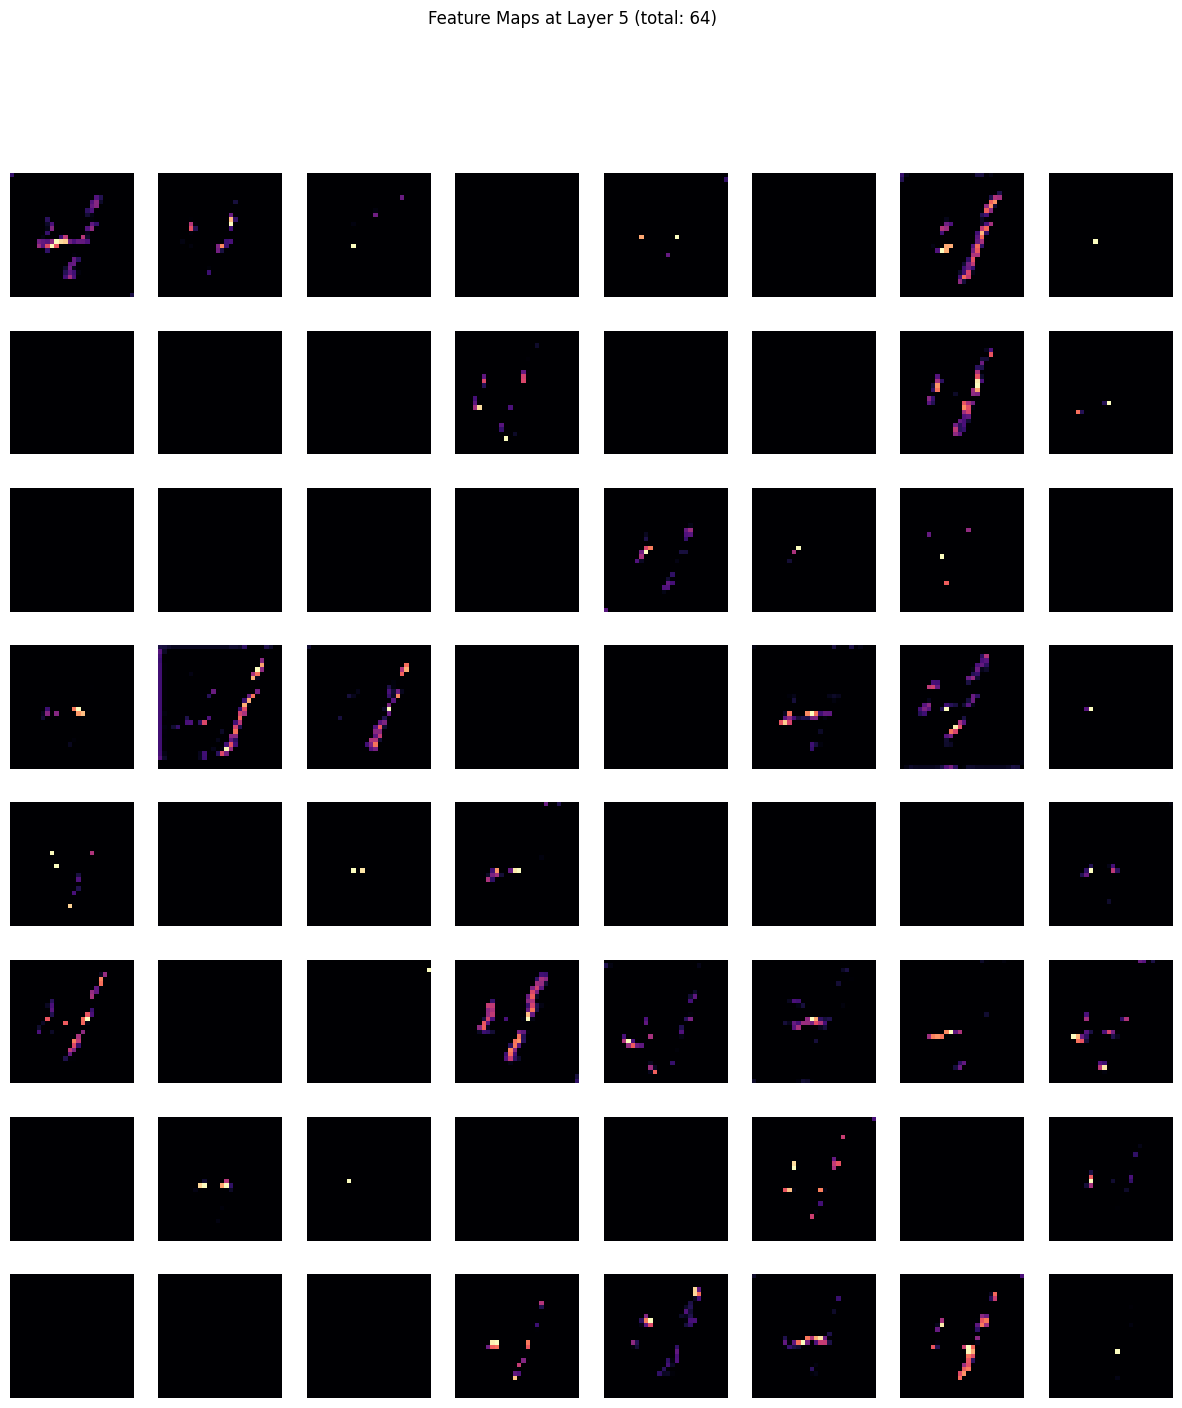

In [111]:
visualize_feature_maps(model, sample_img.unsqueeze(0), layer_idx=5)

In [115]:
model[7]

Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

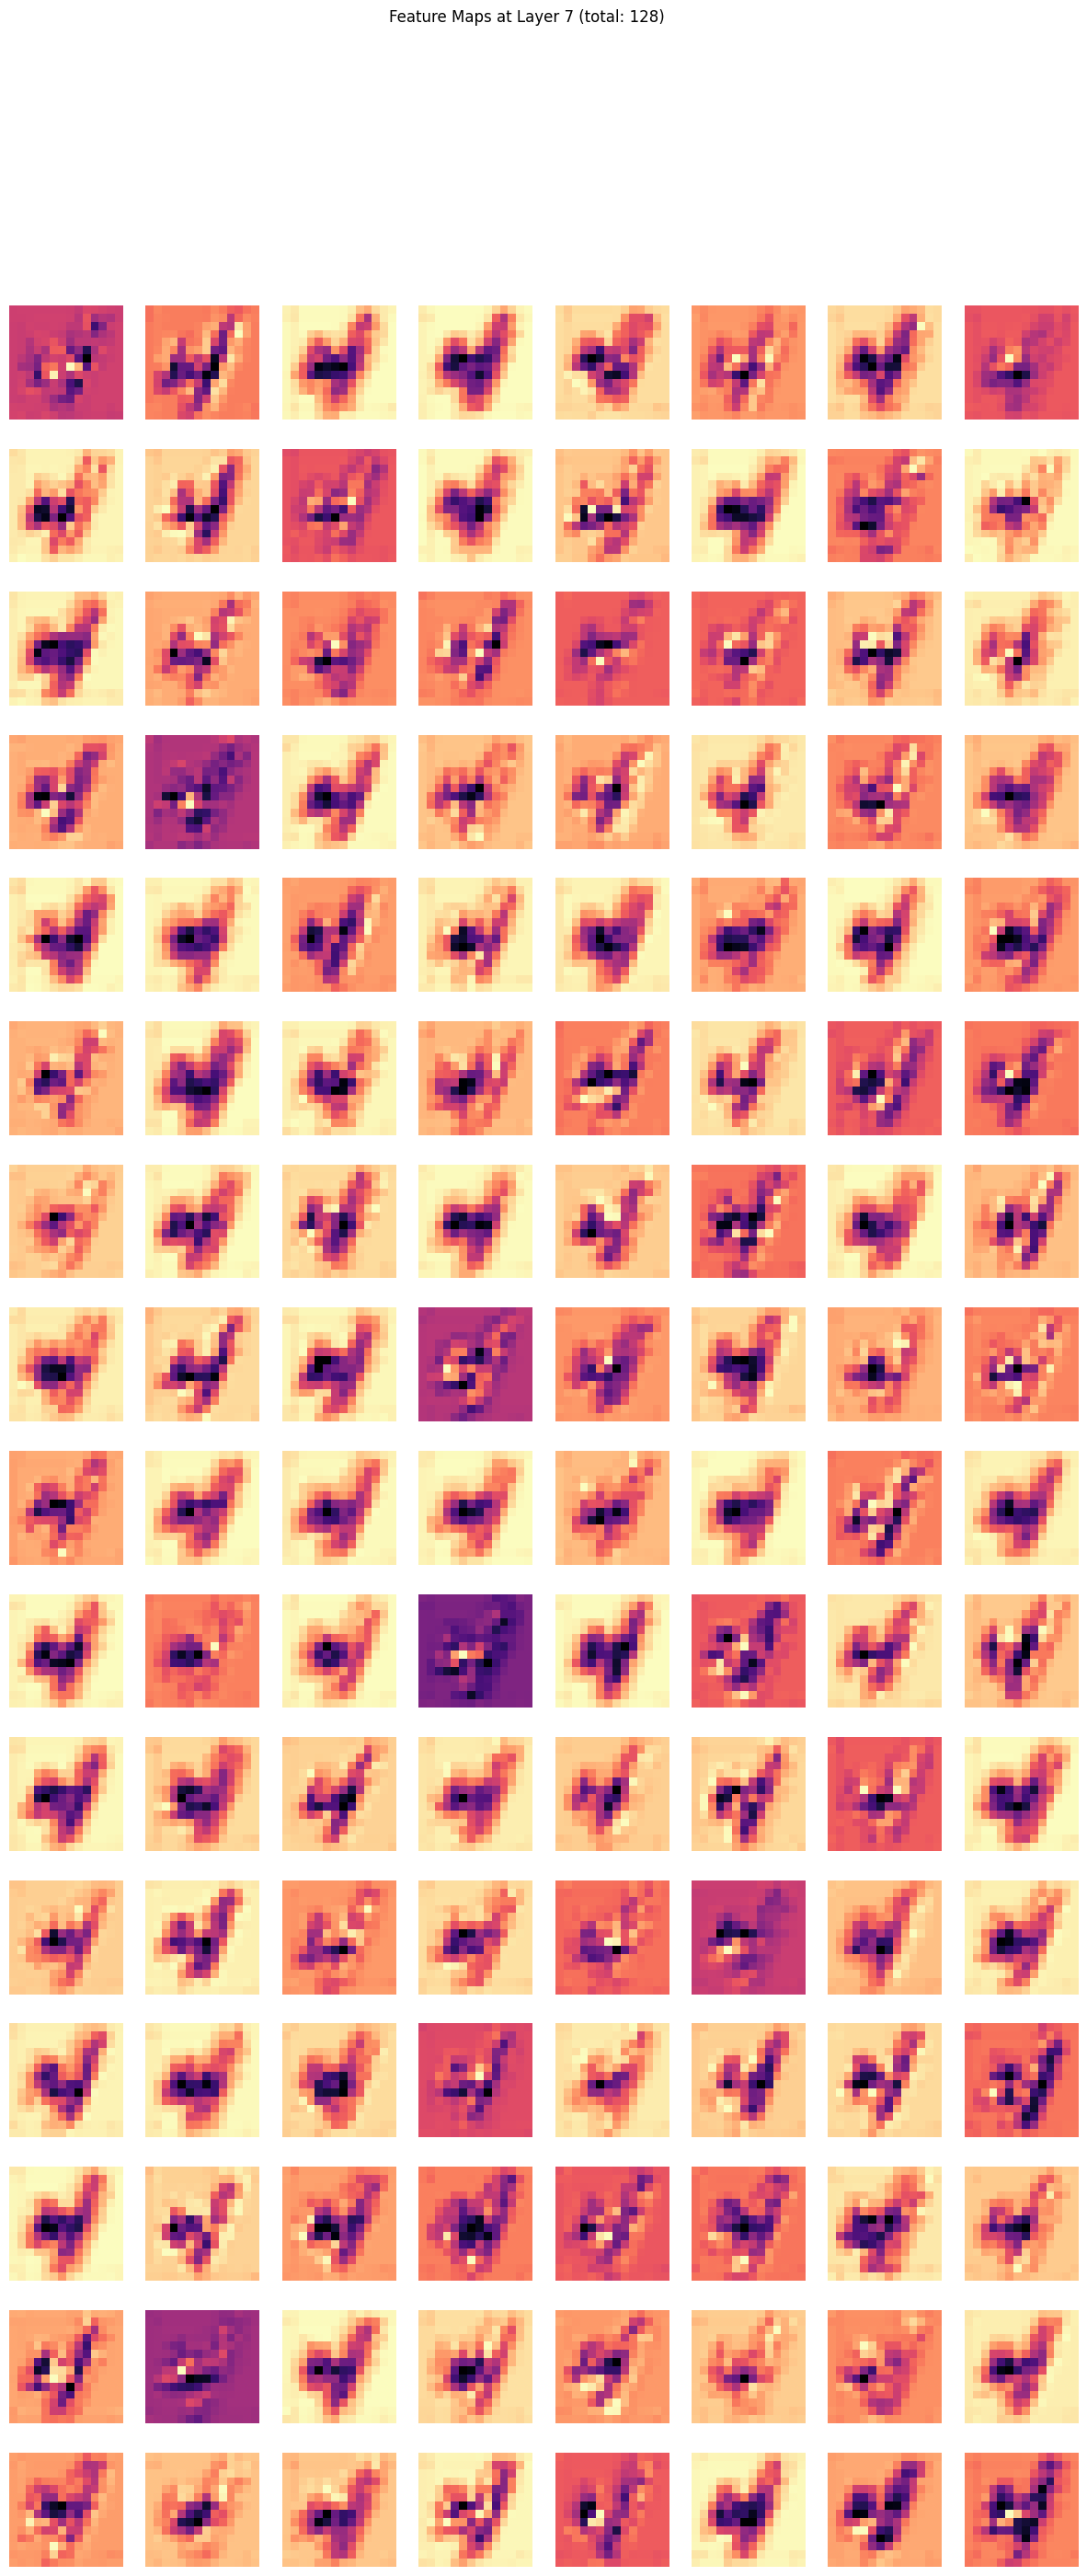

In [114]:
visualize_feature_maps(model, sample_img.unsqueeze(0), layer_idx=7)

Honestly? Curious if it can get any better or if it will diverge at this point. So let's see:

In [146]:
torch.manual_seed(42)

n_epochs = 20 # 20 more steps

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=len(train_and_valid_data.classes)
).to(device)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=0.00001
)

model.train()
history = train(
    model,
    optimizer,
    xentropy,
    accuracy,
    train_loader,
    valid_loader,
    n_epochs,
    scheduler=cosine_scheduler
)

Epoch 1/20, train loss: 0.0069, train metric: 0.9980, valid metric: 0.9942
Epoch 2/20, train loss: 0.0069, train metric: 0.9978, valid metric: 0.9944
Epoch 3/20, train loss: 0.0067, train metric: 0.9979, valid metric: 0.9942
Epoch 4/20, train loss: 0.0053, train metric: 0.9981, valid metric: 0.9930
Epoch 5/20, train loss: 0.0060, train metric: 0.9983, valid metric: 0.9938
Epoch 6/20, train loss: 0.0048, train metric: 0.9986, valid metric: 0.9942
Epoch 7/20, train loss: 0.0047, train metric: 0.9983, valid metric: 0.9940
Epoch 8/20, train loss: 0.0040, train metric: 0.9986, valid metric: 0.9944
Epoch 9/20, train loss: 0.0039, train metric: 0.9987, valid metric: 0.9932
Epoch 10/20, train loss: 0.0040, train metric: 0.9987, valid metric: 0.9946
Epoch 11/20, train loss: 0.0038, train metric: 0.9989, valid metric: 0.9944
Epoch 12/20, train loss: 0.0032, train metric: 0.9988, valid metric: 0.9942
Epoch 13/20, train loss: 0.0030, train metric: 0.9990, valid metric: 0.9942
Epoch 14/20, train lo

In [147]:
evaluate_tm(model, test_loader, accuracy)

tensor(0.9960, device='cuda:0')

Well I am satisfied with this.